In [ ]:
from qiskit.quantum_info import Statevector

# Get the statevector from VQE result
# The VQEResult object does not store the eigenstate by default.
# Reconstruct the statevector using the optimal parameters and ansatz from the VQE run.
optimal_circuit = ansatz.assign_parameters(vqe_result.optimal_parameters)
sv = Statevector(optimal_circuit)

# Compute probability of each qubit being |1> (Buy)
probabilities = [sv.probabilities([i])[1] for i in range(n_qubits)]  # index 1 is |1>

# Map probabilities to Buy/Hold/Sell signals
signals = []
for p in probabilities:
    if p > 0.7:
        signals.append("Buy")
    elif p < 0.3:
        signals.append("Hold")
    else:
        signals.append("Sell")

# Display
for i, (p, s) in enumerate(zip(probabilities, signals)):
    print(f"Qubit {i}: Probability={p:.2f} → Signal={s}")

Qubit 0: Probability=1.00 → Signal=Buy
Qubit 1: Probability=1.00 → Signal=Buy
Qubit 2: Probability=0.99 → Signal=Buy
Qubit 3: Probability=1.00 → Signal=Buy


Latest Prices:
AAPL: $264.58
MSFT: $397.23
TSLA: $411.82
GOOGL: $314.98

Hamiltonian:
SparsePauliOp(['IIII', 'ZIII', 'IZII', 'IIZI', 'IIIZ', 'XXII', 'IXXI', 'IIXX'],
              coeffs=[ 0. +0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j, -0.1+0.j, -0.1+0.j,
 -0.1+0.j])

Exact ground state energy: -2.0150123692285167
Number of ansatz parameters: 24

VQE ground state energy: -2.0046196067167874
Energy difference (VQE - Exact): 0.01039276251172927

Probabilistic Buy/Hold/Sell signals:
Ticker | Price | Probability | Signal
AAPL   | $264.58 | 1.00       | Buy
MSFT   | $397.23 | 0.99       | Buy
TSLA   | $411.82 | 1.00       | Buy
GOOGL  | $314.98 | 1.00       | Buy


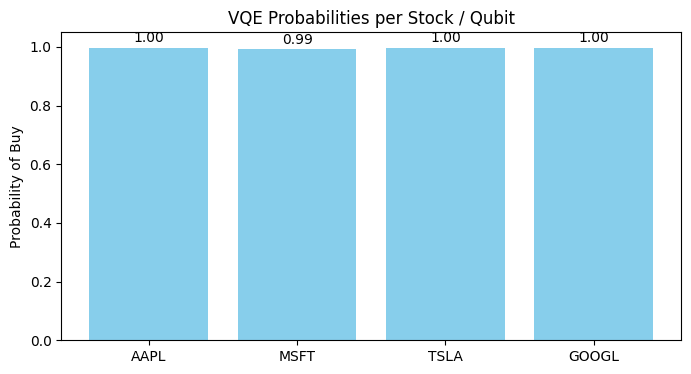

In [ ]:
# ==================================================
# 1️⃣ Install required packages
# ==================================================
!pip install yfinance qiskit matplotlib numpy

# ==================================================
# 2️⃣ Imports
# ==================================================
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA

# ==================================================
# 3️⃣ Define the stocks (map qubits to tickers)
# ==================================================
tickers = ["AAPL", "MSFT", "TSLA", "GOOGL"]  # add up to 8

n_qubits = len(tickers)

# ==================================================
# 4️⃣ Pull recent stock prices (Yahoo Finance)
# ==================================================
prices = {}
for t in tickers:
    data = yf.Ticker(t).history(period="1mo")  # last month
    prices[t] = data['Close'].iloc[-1]  # last closing price

print("Latest Prices:")
for t, p in prices.items():
    print(f"{t}: ${p:.2f}")

# ==================================================
# 5️⃣ Build a simple “Market Hamiltonian”
# ==================================================
# For demonstration, we'll assign Pauli terms for each stock/qubit
paulis = ["I"*n_qubits]  # identity
coeffs = [0.0]

# Add single-qubit Z terms
for i in range(n_qubits):
    z_term = ["I"]*n_qubits
    z_term[i] = "Z"
    paulis.append("".join(z_term))
    coeffs.append(0.5)  # positive coefficient → bullish

# Add some XX correlations (simplified)
for i in range(n_qubits-1):
    xx_term = ["I"]*n_qubits
    xx_term[i] = "X"
    xx_term[i+1] = "X"
    paulis.append("".join(xx_term))
    coeffs.append(-0.1)  # small negative correlation

ham = SparsePauliOp(paulis, coeffs)

print("\nHamiltonian:")
print(ham)

# ==================================================
# 6️⃣ Compute exact classical ground state (reference)
# ==================================================
exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(ham)
print("\nExact ground state energy:", exact_result.eigenvalue.real)

# ==================================================
# 7️⃣ Build Ansatz
# ==================================================
ansatz = efficient_su2(num_qubits=n_qubits, reps=2, entanglement="full")
print("Number of ansatz parameters:", ansatz.num_parameters)

# ==================================================
# 8️⃣ Setup VQE
# ==================================================
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=200)

vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)

# ==================================================
# 9️⃣ Run VQE
# ==================================================
vqe_result = vqe.compute_minimum_eigenvalue(ham)
print("\nVQE ground state energy:", vqe_result.eigenvalue.real)
print("Energy difference (VQE - Exact):", vqe_result.eigenvalue.real - exact_result.eigenvalue.real)

# ==================================================
# 🔹 10️⃣ Probabilistic Buy/Hold/Sell signals
# ==================================================
# The VQEResult object does not store the eigenstate by default.
# Reconstruct the statevector using the optimal parameters and ansatz from the VQE run.
optimal_circuit = ansatz.assign_parameters(vqe_result.optimal_parameters)
sv = Statevector(optimal_circuit)

# Probability of qubit |1> (Buy)
probabilities = [sv.probabilities([i])[1] for i in range(n_qubits)]

signals = []
for p in probabilities:
    if p > 0.7:
        signals.append("Buy")
    elif p < 0.3:
        signals.append("Hold")
    else:
        signals.append("Sell")

# Display table
print("\nProbabilistic Buy/Hold/Sell signals:")
print("Ticker | Price | Probability | Signal")
for t, p_val, s in zip(tickers, probabilities, signals):
    print(f"{t:6} | ${prices[t]:6.2f} | {p_val:.2f}       | {s}")

# ==================================================
# 🔹 11️⃣ Optional bar chart
# ==================================================
plt.figure(figsize=(8,4))
plt.bar(tickers, probabilities, color='skyblue')
plt.ylim(0, 1.05)
plt.ylabel("Probability of Buy")
plt.title("VQE Probabilities per Stock / Qubit")
for i, p_val in enumerate(probabilities):
    plt.text(i, p_val + 0.02, f"{p_val:.2f}", ha='center')
plt.show()

Latest Prices & Volatility:
AAPL: $264.58, Volatility=0.0141
MSFT: $397.23, Volatility=0.0196
TSLA: $411.82, Volatility=0.0240
GOOGL: $314.98, Volatility=0.0161
AMZN: $210.11, Volatility=0.0174
NVDA: $189.82, Volatility=0.0207
META: $655.66, Volatility=0.0222
NFLX: $78.67, Volatility=0.0174

Hamiltonian:
SparsePauliOp(['IIIIIIII', 'ZIIIIIII', 'IZIIIIII', 'IIZIIIII', 'IIIZIIII', 'IIIIZIII', 'IIIIIZII', 'IIIIIIZI', 'IIIIIIIZ', 'XXIIIIII', 'IXXIIIII', 'IIXXIIII', 'IIIXXIII', 'IIIIXXII', 'IIIIIXXI', 'IIIIIIXX'],
              coeffs=[ 0.        +0.j,  0.02817773+0.j,  0.03913848+0.j,  0.04798867+0.j,
  0.03225915+0.j,  0.03482594+0.j,  0.04137018+0.j,  0.04442892+0.j,
  0.03484258+0.j, -0.01682905+0.j, -0.02178179+0.j, -0.02006196+0.j,
 -0.01677127+0.j, -0.01904903+0.j, -0.02144977+0.j, -0.01981788+0.j])

Exact ground state energy: -0.32023233051357053
Number of ansatz parameters: 48

VQE ground state energy: -0.27088615413531414
Energy difference (VQE - Exact): 0.04934617637825639

Probab

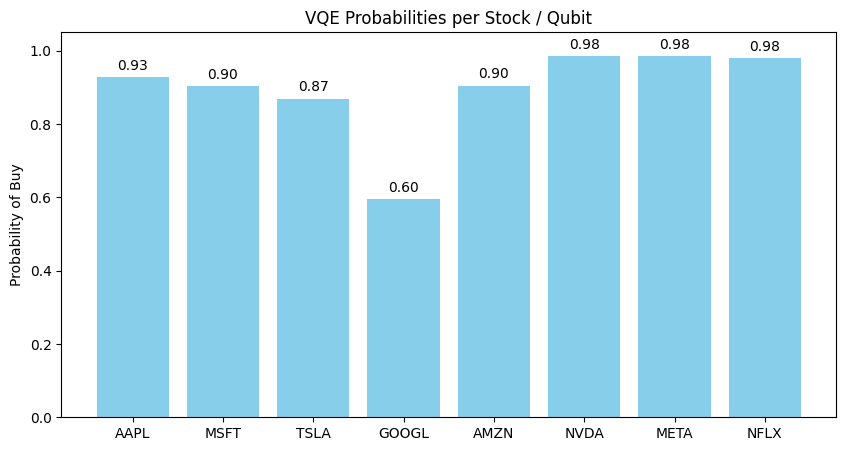

In [ ]:
# ==================================================
# 1️⃣ Install packages
# ==================================================
!pip install yfinance qiskit matplotlib numpy

# ==================================================
# 2️⃣ Imports
# ==================================================
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA

# ==================================================
# 3️⃣ Define 8–10 tickers
# ==================================================
tickers = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN", "NVDA", "META", "NFLX"]

n_qubits = len(tickers)

# ==================================================
# 4️⃣ Pull stock history & compute volatility
# ==================================================
prices = {}
volatility = {}

for t in tickers:
    data = yf.Ticker(t).history(period="3mo")  # last 3 months
    prices[t] = data['Close'].iloc[-1]  # last closing price
    # Daily returns
    returns = data['Close'].pct_change().dropna()
    volatility[t] = returns.std()  # standard deviation as volatility

print("Latest Prices & Volatility:")
for t in tickers:
    print(f"{t}: ${prices[t]:.2f}, Volatility={volatility[t]:.4f}")

# ==================================================
# 5️⃣ Build Hamiltonian (volatility-weighted)
# ==================================================
paulis = ["I"*n_qubits]  # identity
coeffs = [0.0]

# Single-qubit Z terms weighted by volatility
for i, t in enumerate(tickers):
    z_term = ["I"]*n_qubits
    z_term[i] = "Z"
    paulis.append("".join(z_term))
    coeffs.append(volatility[t]*2)  # scale volatility to positive coefficient → bullish

# Add XX correlations between consecutive qubits
for i in range(n_qubits-1):
    xx_term = ["I"]*n_qubits
    xx_term[i] = "X"
    xx_term[i+1] = "X"
    paulis.append("".join(xx_term))
    # Negative correlation proportional to avg volatility
    coeffs.append(-0.5 * (volatility[tickers[i]] + volatility[tickers[i+1]]))

ham = SparsePauliOp(paulis, coeffs)
print("\nHamiltonian:")
print(ham)

# ==================================================
# 6️⃣ Classical reference ground state
# ==================================================
exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(ham)
print("\nExact ground state energy:", exact_result.eigenvalue.real)

# ==================================================
# 7️⃣ Build Ansatz
# ==================================================
ansatz = efficient_su2(num_qubits=n_qubits, reps=2, entanglement="full")
print("Number of ansatz parameters:", ansatz.num_parameters)

# ==================================================
# 8️⃣ Setup VQE
# ==================================================
estimator = StatevectorEstimator()
optimizer = COBYLA(maxiter=200)

vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)

# ==================================================
# 9️⃣ Run VQE
# ==================================================
vqe_result = vqe.compute_minimum_eigenvalue(ham)
print("\nVQE ground state energy:", vqe_result.eigenvalue.real)
print("Energy difference (VQE - Exact):", vqe_result.eigenvalue.real - exact_result.eigenvalue.real)

# ==================================================
# 🔹 10️⃣ Probabilistic Buy/Hold/Sell signals
# ==================================================
# The VQEResult object does not store the eigenstate by default.
# Reconstruct the statevector using the optimal parameters and ansatz from the VQE run.
optimal_circuit = ansatz.assign_parameters(vqe_result.optimal_parameters)
sv = Statevector(optimal_circuit)

probabilities = [sv.probabilities([i])[1] for i in range(n_qubits)]

signals = []
for p in probabilities:
    if p > 0.7:
        signals.append("Buy")
    elif p < 0.3:
        signals.append("Hold")
    else:
        signals.append("Sell")

# Display table
print("\nProbabilistic Buy/Hold/Sell signals:")
print("Ticker | Price | Volatility | Probability | Signal")
for t, p_val, s in zip(tickers, probabilities, signals):
    print(f"{t:6} | ${prices[t]:6.2f} | {volatility[t]:.4f}     | {p_val:.2f}       | {s}")

# ==================================================
# 🔹 11️⃣ Optional bar chart
# ==================================================
plt.figure(figsize=(10,5))
plt.bar(tickers, probabilities, color='skyblue')
plt.ylim(0, 1.05)
plt.ylabel("Probability of Buy")
plt.title("VQE Probabilities per Stock / Qubit")
for i, p_val in enumerate(probabilities):
    plt.text(i, p_val + 0.02, f"{p_val:.2f}", ha='center')
plt.show()

In [ ]:
import numpy as np

!pip install qiskit
!pip install qiskit-algorithms

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver


# -------------------------------------------------
# 1. Define the Market Hamiltonian
# -------------------------------------------------

paulis = [
    "IIII",
    "ZIII", "XXII", "YYII", "XIXI", "YIYI", "XIIX", "YIIY",
    "IZII", "IXXI", "IYYI", "IXIX", "IYIY",
    "IIZI", "IIXX", "IIYY",
    "IIIZ"
]

coeffs = [
    0.0,
    0.5, -0.15, -0.15, -0.1, -0.1, -0.05, -0.05,
    0.6, -0.125, -0.125, -0.075, -0.075,
    0.4, -0.1, -0.1,
    0.7
]

ham = SparsePauliOp(paulis, coeffs)
n_qubits = ham.num_qubits

print("\nHamiltonian (market operator):")
print(ham)


# -------------------------------------------------
# 2. Exact Classical Ground State (for comparison)
# -------------------------------------------------

exact_solver = NumPyMinimumEigensolver()
exact_result = exact_solver.compute_minimum_eigenvalue(ham)

print("\nExact ground state energy: {:.6f}".format(
    exact_result.eigenvalue.real
))


# -------------------------------------------------
# 3. Build Ansatz (Modern API)
# -------------------------------------------------

ansatz = efficient_su2(
    num_qubits=n_qubits,
    reps=2,
    entanglement="full"
)

print("\nNumber of ansatz parameters:", ansatz.num_parameters)


# -------------------------------------------------
# 4. Setup VQE (V2 Primitive Compatible)
# -------------------------------------------------

estimator = StatevectorEstimator()  # V2 primitive (required)
optimizer = COBYLA(maxiter=200)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)


# -------------------------------------------------
# 5. Run VQE
# -------------------------------------------------

vqe_result = vqe.compute_minimum_eigenvalue(ham)

print("\nVQE ground state energy: {:.6f}".format(
    vqe_result.eigenvalue.real
))

print("\nEnergy difference (VQE - Exact): {:.6f}".format(
    vqe_result.eigenvalue.real - exact_result.eigenvalue.real
))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.4 MB/s eta 0:00:00

Hamiltonian (market operator):
SparsePauliOp(['IIII', 'ZIII', 'XXII', 'YYII', 'XIXI', 'YIYI', 'XIIX', 'YIIY', 'IZII', 'IXXI', 'IYYI', 'IXIX', 'IYIY', 'IIZI', 'IIXX', 'IIYY', 'IIIZ'],
              coeffs=[ 0.   +0.j,  0.5  +0.j, -0.15 +0.j, -0.15 +0.j, -0.1  +0.j, -0.1  +0.j,
 -0.05 +0.j, -0.05 +0.j,  0.6  +0.j, -0.125+0.j, -0.125+0.j, -0.075+0.j,
 -0.075+0.j,  0.4  +0.j, -0.1  +0.j, -0.1  +0.j,  0.7  +0.j])

Exact ground state energy: -2.200000

Number of ansatz parameters: 24

VQE ground state energy: -2.192373

Energy difference (VQE - Exact): 0.007627
